In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("store_customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [30]:
df.shape

(1000, 5)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [32]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [33]:
df = df.dropna()

In [34]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [35]:
df.shape

(982, 5)

In [36]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,982.000000,982.000000,982.000000,982.000000
mean,1500.304481,38.958248,57.326782,42.603870
std,288.698083,13.417748,28.658961,20.121469
min,1000.000000,18.000000,15.000000,1.000000
25%,1251.250000,30.000000,35.125000,31.000000
50%,1499.500000,36.000000,49.150000,47.000000
75%,1750.750000,44.000000,79.475000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


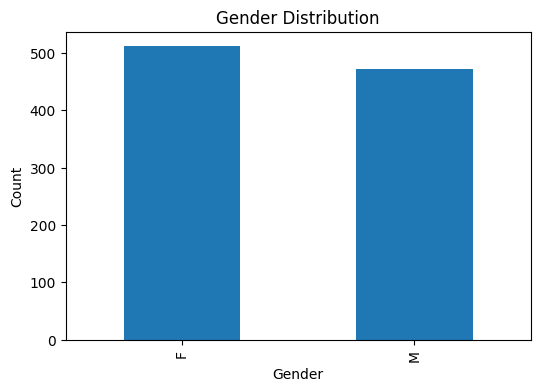

In [37]:
df["Gender"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

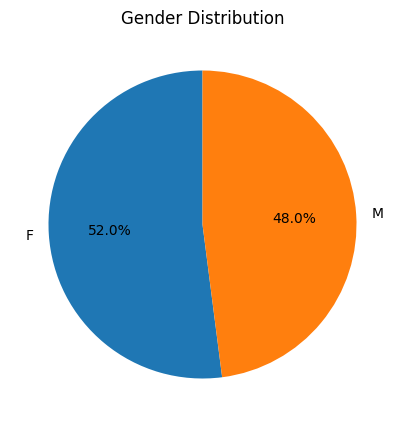

In [38]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

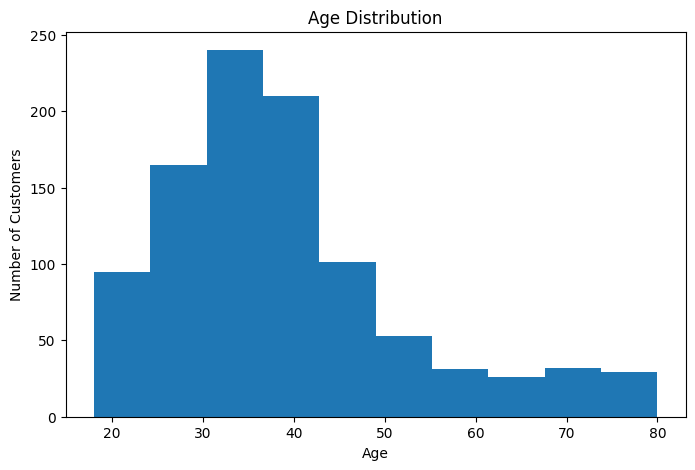

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

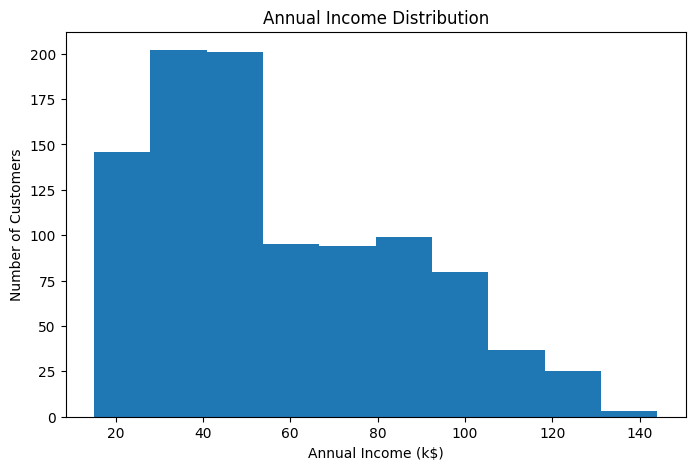

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=10)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

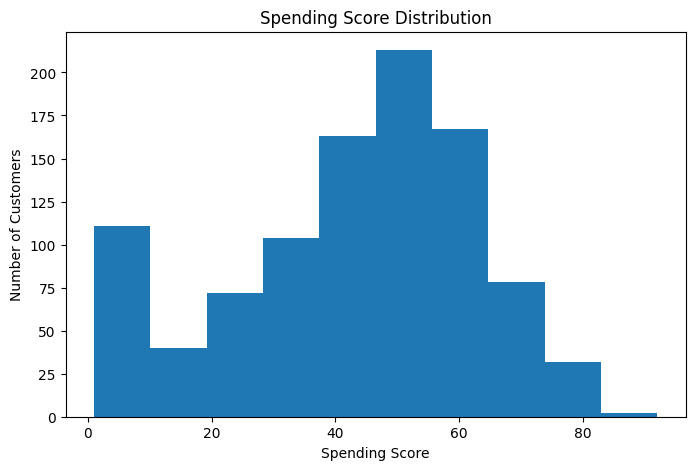

In [41]:
plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=10)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

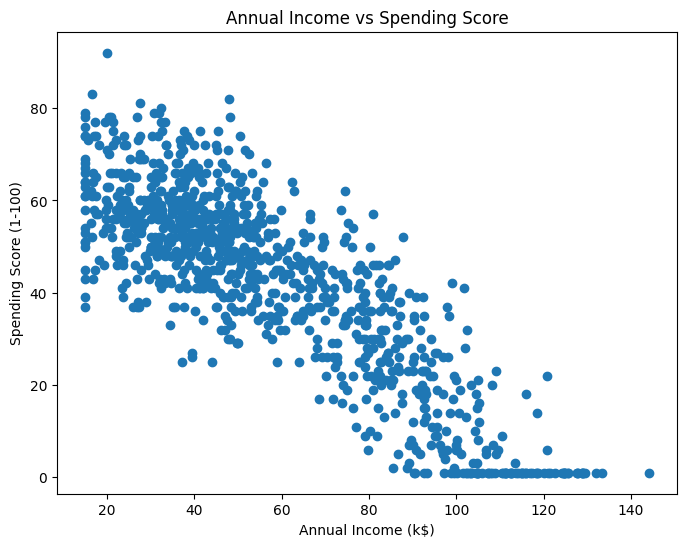

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

In [43]:
df.corr(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,0.383749,0.328675,-0.367117
Age,0.383749,1.000000,0.924309,-0.836341
Annual Income (k$),0.328675,0.924309,1.000000,-0.847945
Spending Score (1-100),-0.367117,-0.836341,-0.847945,1.000000


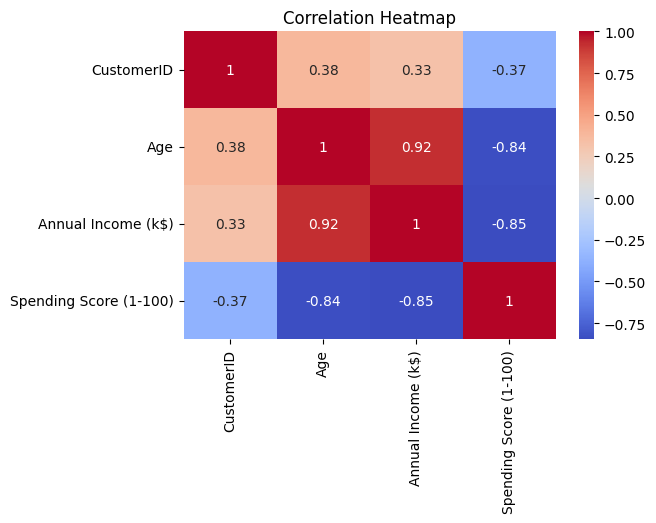

In [44]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [45]:
from sklearn.cluster import KMeans

In [46]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [47]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [48]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [49]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,982.000000,982.000000
mean,57.326782,42.603870
std,28.658961,20.121469
min,15.000000,1.000000
25%,35.125000,31.000000
50%,49.150000,47.000000
75%,79.475000,57.000000
max,144.100000,92.000000


In [50]:
print(X.isnull().sum())

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [51]:
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                  59.9                    58.0
1                  48.4                    37.0
2                  70.5                    26.0
3                  81.1                    30.0
4                  42.1                    58.0
..                  ...                     ...
995               133.3                     1.0
996                82.6                    40.0
997                67.7                    26.0
998                45.7                    59.0
999               107.8                     1.0

[982 rows x 2 columns]


In [52]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

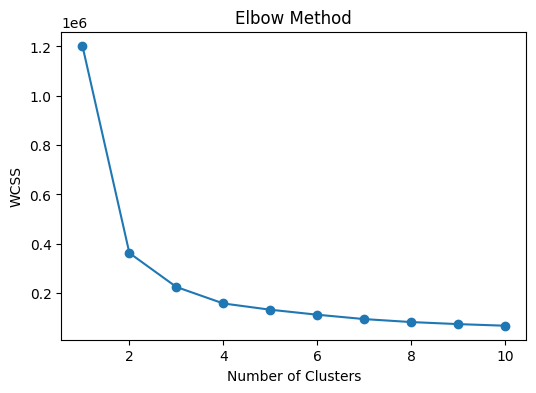

In [53]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [54]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,0
1,1001,M,34.0,48.4,37.0,0
2,1002,F,40.0,70.5,26.0,1
3,1003,F,47.0,81.1,30.0,1
4,1004,F,33.0,42.1,58.0,3


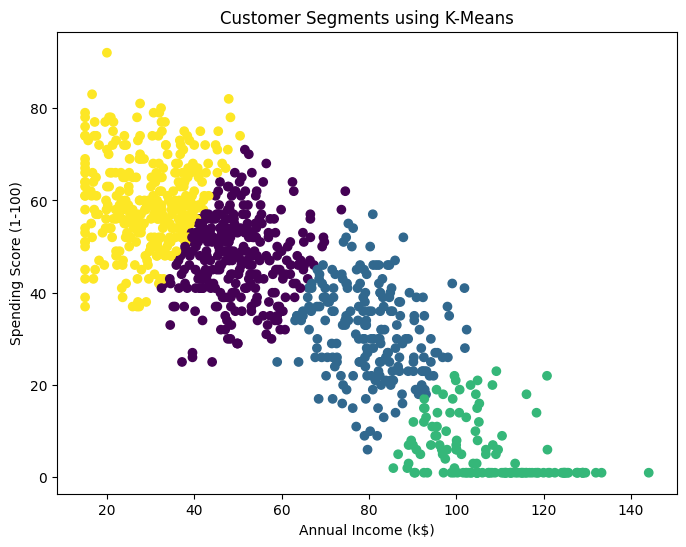

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.show()

In [56]:
df.to_csv("store_customers.csv", index=False)

In [57]:
print("""
Conclusion:

1. Customers were divided into 4 clusters using K-Means.
2. Annual Income and Spending Score were used for segmentation.
3. The clusters help identify different customer groups.
4. Businesses can target customers with personalized marketing strategies.
""")


Conclusion:

1. Customers were divided into 4 clusters using K-Means.
2. Annual Income and Spending Score were used for segmentation.
3. The clusters help identify different customer groups.
4. Businesses can target customers with personalized marketing strategies.

